# Sentiment Analysis with LinearSVC and Logisitc Regression
**Author:** [Arjuna Hellingman],
**Group:**  [4],
**Date:** [01-06-2025],


## 1. Introduction
- Goal: Compare the LinearSVC and the Logistic Regression for sentiment analysis
- Dataset: TweetEval as training data + sentiment-topic-test.tsv file
- Classes: Negative(0), Neutral(1), Postive(2)
- important steps:
    1. Data loading and preprocessing training data
    2. Feature engineering (TF-IDF)
    3. Train SVC and Logistic Regression model and validation
    4. Test set evaluation and load in the test set
    5. Error analysis


In [12]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import re


## 2. Data Loading & Preprocessing

### For the Processing Steps:
    1. Convert to lowercase
    2. Remove URLs, hastags and mentions
    3. remove punctuation
    4. Remove extra spaces
    

In [13]:
# Load in the training dataset
train_dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment", split="train")

# Create a function to preprocess the tweets from the trainging dataset
def preprocess_test(tweet):
    text = tweet['text'].lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text) # remove urls
    text = re.sub(r'@\w+', '', text) # remove mentions
    text = re.sub(r'#', '', text)  # remove hastags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove unnecessary spaces
    return text, tweet['label']  # return processed text and label



preprocessed_tweets = [preprocess_test(tweet) for tweet in train_dataset] # zip the preporcessed traing set by the text and label in a tuple


In [14]:
# 1. Load tweet_eval training split
train_df = pd.DataFrame(preprocessed_tweets, columns=["text", "label"])

# convert label to categotical values
label_map = {0: "negative", 1: "neutral", 2: "positive"}
target_names = [label_map[i] for i in sorted(label_map.keys())]


# 2. Split into training and validation sets
X_train_val = train_df["text"]
y_train_val = train_df["label"]

# train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    random_state=42,
    stratify=y_train_val
)

## 3. Feature engineering (TF-IDF)

### The parameters:
- stop_words="english", removes common English words
- max_df=0.95, removes terms that appear >95%
- min_df=2 ignoring terms appering in <2 documents
- ngram_range=(1,2) includes unigrams and bigrams

In [15]:
# 3. Vectorize the traing data using TF-IDF 
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.95, min_df=2, ngram_range=(1,2))

# converting the traing and validation data into TF-IDF vectors
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

## 4. Train SVC and Logistic Regression model and validation

## Model training:
   ### LinearSVC:
         - handels Class-weigthed to handle imbalance
         - L2 penalty for Regression
   
   ### Logistic Regression:
         - max interaction increased to 1000 for convergence
         - balanced class weights

In [16]:
# create a LinearSVC model and balancing the classes regrading the training set imbalancing
svm_model = LinearSVC( random_state=42, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

logreg_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
logreg_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# reviewing the model prefroamnce on the traing set
val_preds_svm = svm_model.predict(X_val_tfidf)
val_preds_logreg = logreg_model.predict(X_val_tfidf)

print("Validation Classification Report (SVM):")
print(classification_report(y_val, val_preds_svm))

print("Validation Classification Report (Logistic Regression):")
print(classification_report(y_val, val_preds_logreg))

Validation Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      1773
           1       0.64      0.64      0.64      5169
           2       0.67      0.67      0.67      4462

    accuracy                           0.63     11404
   macro avg       0.60      0.60      0.60     11404
weighted avg       0.63      0.63      0.63     11404

Validation Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.45      0.60      0.51      1773
           1       0.67      0.62      0.64      5169
           2       0.70      0.67      0.68      4462

    accuracy                           0.63     11404
   macro avg       0.61      0.63      0.61     11404
weighted avg       0.65      0.63      0.64     11404



## 5. Test set evaluation and load in the test set

In [18]:
# laoding in the test dataset
test_df = pd.read_csv("sentiment-topic-test.tsv", sep="\t")
X_test = test_df["sentence"]

In [19]:
# 1. Preprocess the test sentences
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_test_processed = [preprocess_text(text) for text in X_test]

In [20]:
# 2. Vectorize the test data
X_test_vec = vectorizer.transform(X_test_processed)  # assuming TF-IDF vectorizer was used

# 3. Predict on test set
test_preds_svm = svm_model.predict(X_test_vec)
test_preds_logreg = logreg_model.predict(X_test_vec)

# Ensure y_test_numeric is properly mapped to numeric values
y_test_numeric = test_df["sentiment"].map({"negative": 0, "neutral": 1, "positive": 2})

# Print classification reports
print("SVM Test Classification Report:")
print(classification_report(y_test_numeric, test_preds_svm, target_names=target_names))

print("\nLogistic Regression Test Classification Report:")
print(classification_report(y_test_numeric, test_preds_logreg, target_names=target_names))



SVM Test Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.67      0.80         6
     neutral       0.56      0.83      0.67         6
    positive       0.60      0.50      0.55         6

    accuracy                           0.67        18
   macro avg       0.72      0.67      0.67        18
weighted avg       0.72      0.67      0.67        18


Logistic Regression Test Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.83      0.83         6
     neutral       1.00      0.83      0.91         6
    positive       0.71      0.83      0.77         6

    accuracy                           0.83        18
   macro avg       0.85      0.83      0.84        18
weighted avg       0.85      0.83      0.84        18



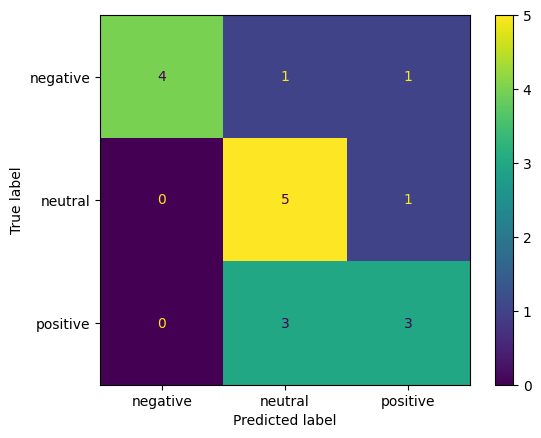

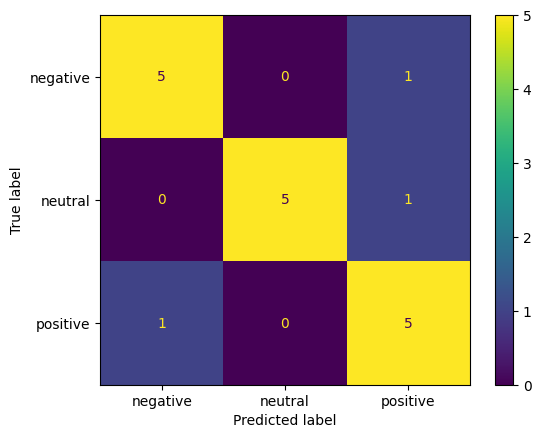

In [21]:

# Display confusion matrices for both SVM and Logistic Regression models
# the counts of true vs predicted labels for each class
cm = confusion_matrix(y_test_numeric, test_preds_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()

cm = confusion_matrix(y_test_numeric, test_preds_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()

  ## 6. Error analysis

In [22]:
# to map the numeric values back to string labels for readability
label_map_back = {0: "negative", 1: "neutral", 2: "positive"}

# Create DataFrames for SVM and Logistic Regression results
results_df_svc = pd.DataFrame({
    "sentence": test_df["sentence"],
    "true_label": y_test_numeric,
    "pred_label": test_preds_svm
})

results_df_logreg = pd.DataFrame({
    "sentence": test_df["sentence"],
    "true_label": y_test_numeric,
    "pred_label": test_preds_logreg
})

# Filter misclassified samples with .copy()
misclassified_df_svc = results_df_svc[results_df_svc["true_label"] != results_df_svc["pred_label"]].copy()
misclassified_df_logreg = results_df_logreg[results_df_logreg["true_label"] != results_df_logreg["pred_label"]].copy()

# Map numeric labels back to string labels for readability for both true and predicted
misclassified_df_svc["true_label_str"] = misclassified_df_svc["true_label"].map(label_map_back)
misclassified_df_svc["pred_label_str"] = misclassified_df_svc["pred_label"].map(label_map_back)

misclassified_df_logreg["true_label_str"] = misclassified_df_logreg["true_label"].map(label_map_back)
misclassified_df_logreg["pred_label_str"] = misclassified_df_logreg["pred_label"].map(label_map_back)

# Display the first 10 misclassified samples for SVC
print("\nMisclassified samples for SVC:\n")
for idx, row in misclassified_df_svc.iterrows():
    print(f"Text: {row['sentence']}")
    print(f"True label: {row['true_label_str']}")
    print(f"Predicted label: {row['pred_label_str']}")
    print("---")

# Display the first 10 misclassified samples for Logistic Regression
print("\nMisclassified samples for Logistic Regression:\n")
for idx, row in misclassified_df_logreg.iterrows():
    print(f"Text: {row['sentence']}")
    print(f"True label: {row['true_label_str']}")
    print(f"Predicted label: {row['pred_label_str']}")
    print("---")




Misclassified samples for SVC:

Text: I enjoyed the way the timelines shifted, even if it got a little confusing sometimes.
True label: neutral
Predicted label: positive
---
Text: Every time I watch this movie, I notice something new—it really grows on you.
True label: positive
Predicted label: neutral
---
Text: The movie was a wild ride from start to finish; I was on the edge of my seat the entire time.
True label: positive
Predicted label: neutral
---
Text: Honestly, the team just fell apart in the second half, and it showed on the field.
True label: negative
Predicted label: neutral
---
Text: The author's style feels really genuine, making each sentence resonate.
True label: positive
Predicted label: neutral
---
Text: In the end, the book was more useful as a coaster than as something worth reading.
True label: negative
Predicted label: positive
---

Misclassified samples for Logistic Regression:

Text: I enjoyed the way the timelines shifted, even if it got a little confusing some